# Showcase — NO₂ over China and the 2020 COVID lockdown (Sentinel-5P)

When China locked down in early 2020, traffic and industry collapsed and the fall in air pollution was visible from orbit. **Sentinel-5P/TROPOMI** maps tropospheric NO₂. This notebook maps Feb–Mar 2019 vs 2020 with pyramids' `Dataset.plot()` and builds a three-year monthly time series.

## What this notebook does

1. **Map** mean NO₂ for Feb–Mar 2019, 2020 and the difference with `Dataset.plot()`.
2. **Build a monthly time series** 2019–2021 (the seasonal cycle, lockdown dip, rebound).

> Needs `GEE_SERVICE_ACCOUNT` / `GEE_SERVICE_KEY` and `pyramids-gis[viz]`.

In [1]:
import os, tempfile, base64
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from loguru import logger
from IPython.display import HTML, display
from earthlens import EarthLens
from pyramids.dataset import Dataset, DatasetCollection   # pyramids' own plotting

logger.disable("earthlens"); logger.disable("pyramids")
SERVICE_ACCOUNT = os.environ.get("GEE_SERVICE_ACCOUNT", "my-sa@my-project.iam.gserviceaccount.com")
SERVICE_KEY = os.environ.get("GEE_SERVICE_KEY", "/path/to/key.json")

def grab(collection, aoi, start, end, bands, scale, reducer="median"):
    el = EarthLens(data_source="gee", start=start, end=end, temporal_resolution="raw",
        variables={collection: list(bands)}, lat_lim=[aoi[1], aoi[3]], lon_lim=[aoi[0], aoi[2]],
        path=tempfile.mkdtemp(), scale=scale, reducer=reducer,
        service_account=SERVICE_ACCOUNT, service_key=SERVICE_KEY)
    try:
        p = el.download(progress_bar=False)
    except Exception as exc:  # noqa: BLE001
        print("download skipped (needs GEE credentials):", exc); return None
    return str(p[0]) if p else None

def read(path):
    return np.asarray(Dataset.read_file(str(path)).read_array(), dtype="float32")

def plot_band_array(values, like_path, ax, cmap, title, **kw):
    """Render a derived single-band array (NDVI, dNBR, NO2, ...) with Dataset.plot
    by wrapping it back into a Dataset that carries the source georeferencing."""
    src = Dataset.read_file(str(like_path))
    ds = Dataset.create_from_array(arr=values[None, :, :].astype("float32"),
                                   geo=src.geotransform, epsg=src.epsg)
    return ds.plot(band=0, ax=ax, cmap=cmap, title=title, **kw)

def animate_collection(files, band, title, cmap=None, fps=1):
    glyph = DatasetCollection.from_files(files).plot(band=band, title=title, cmap=cmap)
    gif = os.path.join(tempfile.mkdtemp(), "anim.gif"); glyph.save_animation(gif, fps=fps)
    return HTML(f'<img src="data:image/gif;base64,{base64.b64encode(open(gif,"rb").read()).decode()}" style="max-width:620px"/>')

from datetime import date
AOI = [108.0, 28.0, 122.5, 41.0]; C = "COPERNICUS/S5P/OFFL/L3_NO2"
NO2 = "tropospheric_NO2_column_number_density"
a2019 = grab(C, AOI, "2019-02-01", "2019-03-15", [NO2], scale=7000, reducer="mean")
a2020 = grab(C, AOI, "2020-02-01", "2020-03-15", [NO2], scale=7000, reducer="mean")
print("composites:", bool(a2019), bool(a2020))

composites: True True


## Maps: Feb–Mar 2019 vs 2020 — `Dataset.plot()`

The two years are drawn on a shared colour scale; the difference (a derived array) is wrapped back into a Dataset so it too uses `Dataset.plot()`.

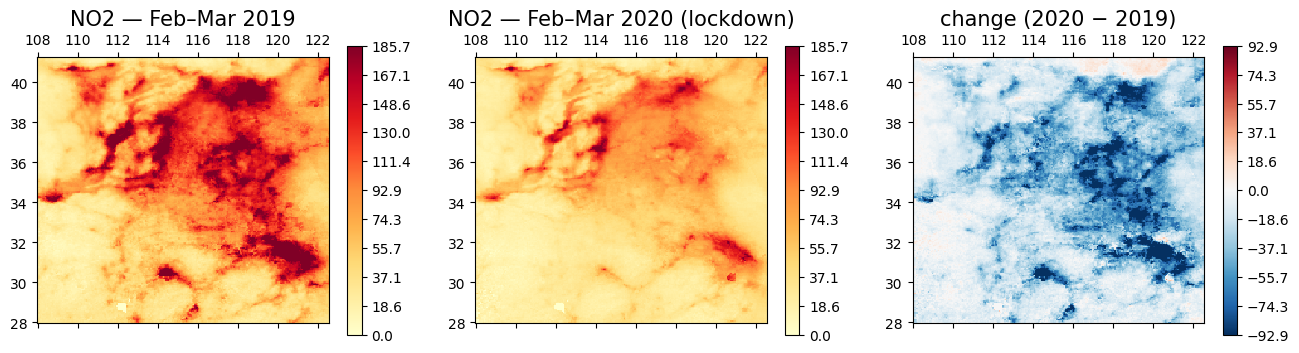

mean tropospheric NO2 fell 36% (Feb–Mar 2020 vs 2019)


In [2]:
# umol/m^2 for readable numbers; shared vmax across the two years.
if a2019 and a2020:
    u = 1e6; n19 = read(a2019); n20 = read(a2020)
    n19 = (n19 if n19.ndim == 2 else n19[0]) * u; n20 = (n20 if n20.ndim == 2 else n20[0]) * u
    vmax = float(np.nanpercentile(np.concatenate([n19.ravel(), n20.ravel()]), 98))
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    plot_band_array(n19, a2019, ax[0], "YlOrRd", "NO2 — Feb–Mar 2019", vmin=0, vmax=vmax)
    plot_band_array(n20, a2020, ax[1], "YlOrRd", "NO2 — Feb–Mar 2020 (lockdown)", vmin=0, vmax=vmax)
    plot_band_array(n20 - n19, a2019, ax[2], "RdBu_r", "change (2020 − 2019)", vmin=-vmax/2, vmax=vmax/2)
    plt.show()
    print(f"mean tropospheric NO2 fell {(1 - np.nanmean(n20)/np.nanmean(n19))*100:.0f}% (Feb–Mar 2020 vs 2019)")

## Monthly time series, 2019–2021

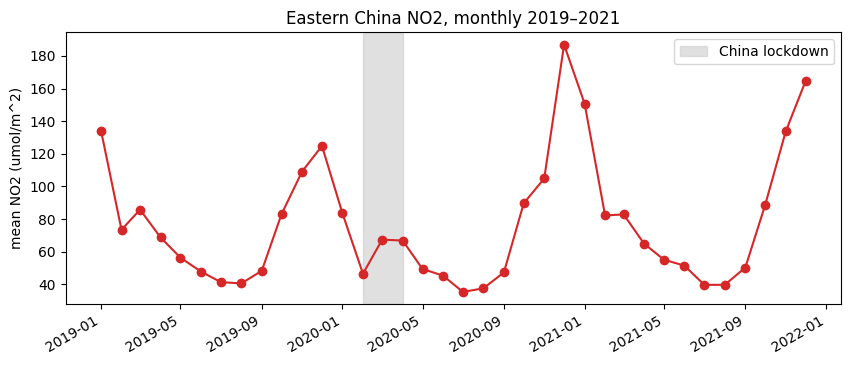

36 monthly composites


In [3]:
# Regional-mean NO2 per month; shade the main lockdown window. (matplotlib chart)
if a2019 and a2020:
    months, vals = [], []
    for y in (2019, 2020, 2021):
        for m in range(1, 13):
            s = date(y, m, 1); e = date(y + (m == 12), (m % 12) + 1, 1)
            p = grab(C, AOI, s.isoformat(), e.isoformat(), [NO2], scale=7000, reducer="mean")
            if p:
                arr = read(p); arr = arr if arr.ndim == 2 else arr[0]
                months.append(pd.Timestamp(s)); vals.append(np.nanmean(arr) * 1e6)
    fig, ax = plt.subplots(figsize=(10, 4)); ax.plot(months, vals, "-o", color="tab:red")
    ax.axvspan(pd.Timestamp("2020-02-01"), pd.Timestamp("2020-04-01"), color="0.8", alpha=0.6, label="China lockdown")
    ax.set(ylabel="mean NO2 (umol/m^2)", title="Eastern China NO2, monthly 2019–2021"); ax.legend(); fig.autofmt_xdate(); plt.show()
    print(f"{len(vals)} monthly composites")

## Recap

The NO₂ maps (including the derived difference) are rendered with `Dataset.plot()`; the monthly time series is a matplotlib chart.

## Try it yourself

- Re-point `AOI`, or compare other year pairs.
- See the [GEE backend reference](../../reference/gee/introduction.md).